In [1]:
!pip install torch

Mounted at /content/drive


In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim


def load_hdf5_mat_file(file_path):
    """
    Load a .mat file and extract hyperspectral image and ground truth data.

    Args:
        file_path (str): Path to the .mat file.

    Returns:
        np.ndarray, np.ndarray: HSI and GT data.
    """
    try:
        data = h5py.File(file_path, 'r')
        hsi_data = np.array(data['HSI'])  # Hyperspectral image data
        gt_data = np.array(data['GT'])   # Ground truth data
        print(f"Loaded file: {file_path}")
        print(f"HSI shape: {hsi_data.shape}, GT shape: {gt_data.shape}")
        return hsi_data, gt_data
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None, None

In [3]:
import os

In [12]:
def split_into_tiles(hsi_data, gt_data, tile_size=32):
    """
    Split HSI and GT data into smaller tiles of size (tile_size x tile_size).

    Args:
        hsi_data (np.ndarray): Hyperspectral image data.
        gt_data (np.ndarray): Ground truth data.
        tile_size (int): Size of the tiles (default: 32x32).

    Returns:
        list, list: HSI tiles and corresponding GT tiles.
    """
    hsi_tiles = []
    gt_tiles = []

    gt_data[gt_data == 0] = 255
    gt_data[gt_data != 255] -= 1

    rows, cols = gt_data.shape
    for i in range(0, rows, tile_size):
        for j in range(0, cols, tile_size):
            hsi_tile = hsi_data[:, i:i + tile_size, j:j + tile_size]
            gt_tile = gt_data[i:i + tile_size, j:j + tile_size]

            # Check if the tile matches the expected size
            if hsi_tile.shape[1:] == (tile_size, tile_size) and gt_tile.shape == (tile_size, tile_size) and np.any(gt_tile != 255):
                hsi_tiles.append(hsi_tile)
                gt_tiles.append(gt_tile)

    return hsi_tiles, gt_tiles


In [5]:
def process_multiple_hsi_files(folder_path, tile_size=32):
    """
    Process multiple .mat files in a folder to create a combined dataset.

    Args:
        folder_path (str): Path to the folder containing .mat files.
        tile_size (int): Size of the tiles (default: 32x32).

    Returns:
        np.ndarray, np.ndarray: Combined HSI tiles and GT tiles.
    """
    combined_hsi_tiles = []
    combined_gt_tiles = []

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.mat'):
            file_path = os.path.join(folder_path, file_name)

            # Load the file
            hsi_data, gt_data = load_hdf5_mat_file(file_path)
            if hsi_data is None or gt_data is None:
                continue

            # Split into tiles
            hsi_tiles, gt_tiles = split_into_tiles(hsi_data, gt_data, tile_size)
            combined_hsi_tiles.extend(hsi_tiles)
            combined_gt_tiles.extend(gt_tiles)

    # Convert to NumPy arrays
    combined_hsi_tiles = np.array(combined_hsi_tiles)
    combined_gt_tiles = np.array(combined_gt_tiles)

    print(f"Total number of HSI tiles: {len(combined_hsi_tiles)}")
    print(f"Total number of GT tiles: {len(combined_gt_tiles)}")

    return combined_hsi_tiles, combined_gt_tiles

In [6]:
folder_path = r"C:\Users\ChloeAtherton\Capstone\data"  # Path to the folder containing .mat files
tile_size = 32

# Process all files in the folder
hsi_tiles, gt_tiles = process_multiple_hsi_files(folder_path, tile_size)

# Verify the combined dataset
print(f"Final dataset shape - HSI tiles: {hsi_tiles.shape}, GT tiles: {gt_tiles.shape}")

Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC12.mat
HSI shape: (270, 2884, 682), GT shape: (2884, 682)
Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC13.mat
HSI shape: (270, 808, 1098), GT shape: (808, 1098)
Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC16.mat
HSI shape: (270, 976, 1060), GT shape: (976, 1060)
Total number of HSI tiles: 2156
Total number of GT tiles: 2156
Final dataset shape - HSI tiles: (2156, 270, 32, 32), GT tiles: (2156, 32, 32)


In [7]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test)
hsi_train, hsi_test, gt_train, gt_test = train_test_split(
    hsi_tiles, gt_tiles, test_size=0.2, random_state=42
)

print(f"Train set: {len(hsi_train)} samples")
print(f"Test set: {len(hsi_test)} samples")


Train set: 1724 samples
Test set: 432 samples


In [8]:
import torch
import torch.nn as nn

class ResUNet(nn.Module):
    def __init__(self, in_channels=270, num_classes=14):
        super(ResUNet, self).__init__()
        self.num_classes = num_classes

        # Residual block
        def res_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        # Encoder with residual blocks
        self.enc1 = res_block(in_channels, 64)
        self.enc2 = res_block(64, 128)
        self.enc3 = res_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        # 1x1 convolution for residual matching in encoders
        self.res1 = nn.Conv2d(in_channels, 64, kernel_size=1, bias=False)
        self.res2 = nn.Conv2d(64, 128, kernel_size=1, bias=False)
        self.res3 = nn.Conv2d(128, 256, kernel_size=1, bias=False)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = res_block(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = res_block(128, 64)
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder with residual connections
        enc1 = self.enc1(x) + self.res1(x)  # Residual connection on input
        enc2 = self.enc2(self.pool(enc1)) + self.res2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2)) + self.res3(self.pool(enc2))

        # Decoder
        dec3 = self.dec3(torch.cat([self.up3(enc3), enc2], dim=1))
        dec2 = self.dec2(torch.cat([self.up2(dec3), enc1], dim=1))

        return self.final(dec2)


In [9]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import random

class HyperspectralDataset(Dataset):
    def __init__(self, images, masks, hflip=None, vflip=None):
        self.images = images  # Hyperspectral tiles of shape (270, 32, 32)
        self.masks = masks    # Ground truth tiles of shape (32, 32)
        self.hflip = hflip
        self.vflip = vflip

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)  # (270, 32, 32)
        mask = torch.tensor(self.masks[idx], dtype=torch.long)      # (32, 32)
        if self.hflip:
            if random.random() < 0.5:
                image = v2.functional.horizontal_flip(image)
                mask = v2.functional.horizontal_flip(mask)
        if self.vflip:
            if random.random() < 0.5:
                image = v2.functional.vertical_flip(image)
                mask = v2.functional.vertical_flip(mask)
        return image, mask

# Split into training and testing
train_dataset = HyperspectralDataset(hsi_train, gt_train)
test_dataset = HyperspectralDataset(hsi_test, gt_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [10]:
import torch
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

unique_classes = torch.unique(torch.tensor(gt_tiles))
print(f"Unique classes in masks: {unique_classes}")
print(f"Number of classes: {len(unique_classes)}")

for images, masks in train_loader:
    print(f"Input shape: {images.shape}")
    print(f"Ground truth shape: {masks.shape}")
    break


Is CUDA available: False
PyTorch version: 2.6.0+cpu
Using device: cpu
Unique classes in masks: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15, 255], dtype=torch.uint8)
Number of classes: 17
Input shape: torch.Size([8, 270, 32, 32])
Ground truth shape: torch.Size([8, 32, 32])


Using device: cpu
Model is on device: cpu
Epoch 1/70, Training Loss: 1.8711, Validation Loss: 1.6597
Epoch 2/70, Training Loss: 1.5134, Validation Loss: 1.1763
Epoch 3/70, Training Loss: 1.3377, Validation Loss: 1.1221
Epoch 4/70, Training Loss: 1.2913, Validation Loss: 1.0517
Epoch 5/70, Training Loss: 1.1289, Validation Loss: 0.9546
Epoch 6/70, Training Loss: 1.1394, Validation Loss: 0.8197
Epoch 7/70, Training Loss: 1.0420, Validation Loss: 1.2070
Epoch 8/70, Training Loss: 0.9862, Validation Loss: 0.7369
Epoch 9/70, Training Loss: 0.9184, Validation Loss: 0.7075
Epoch 10/70, Training Loss: 0.8450, Validation Loss: 0.8968
Epoch 11/70, Training Loss: 0.8282, Validation Loss: 0.9034
Epoch 12/70, Training Loss: 0.8007, Validation Loss: 0.6649
Epoch 13/70, Training Loss: 0.7630, Validation Loss: 0.7678
Epoch 14/70, Training Loss: 0.7892, Validation Loss: 1.3813
Epoch 15/70, Training Loss: 0.7002, Validation Loss: 0.6268
Epoch 16/70, Training Loss: 0.7634, Validation Loss: 0.6480
Epoch 1

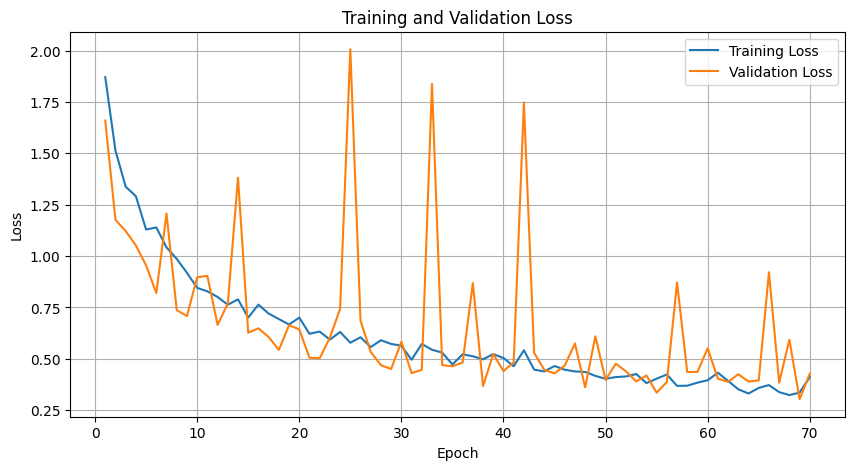

RuntimeError: Parent directory /content/drive/MyDrive/Capstone does not exist.

In [11]:
# TRAINING SCRIPT

import matplotlib.pyplot as plt
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to the correct device
model = ResUNet(in_channels=270, num_classes=17).to(device)
print(f"Model is on device: {next(model.parameters()).device}")

save_file = "/content/drive/MyDrive/Capstone/weights_resunet_32_255.pth"
plot_file = "/content/drive/MyDrive/Capstone/plot_resunet_32_255.png"

# Ensure criterion is defined
criterion = nn.CrossEntropyLoss(ignore_index = 255)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, save_file, plot_file, num_epochs=10):
    model.train()  # Set the model to training mode

    # Store losses for plotting
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        model.train()  # Set the model to training mode

        # Training loop
        for images, masks in train_loader:
            # Check the model's output shape

            # Move data to the appropriate device
            images, masks = images.to(device), masks.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)  # Output: (batch_size, num_classes, H, W)

            # Compute loss
            loss = criterion(outputs, masks)
            running_train_loss += loss.item()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

        # Calculate average training loss for this epoch
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation loop
        running_val_loss = 0.0
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():

            for images, masks in test_loader:
                # Move data to the appropriate device
                images, masks = images.to(device), masks.to(device)

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, masks)
                running_val_loss += loss.item()

        # Calculate average validation loss for this epoch
        avg_val_loss = running_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Plot the losses
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid()
    plt.show()

    if save_file != None:
        torch.save(model.state_dict(), save_file)
    if plot_file != None:
        plt.savefig(plot_file)

    return train_losses, val_losses



train_losses, val_losses = train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, save_file, plot_file, num_epochs=70)



In [13]:
def evaluate_model(model, dataloader, criterion):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_pixels = 0
    iou_scores = []
    dice_scores = []

    with torch.no_grad():  # Disable gradient computation
        for images, masks in dataloader:
            # Move data to the appropriate device
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)  # (batch_size, num_classes, height, width)
            preds = torch.argmax(outputs, dim=1)  # Predicted class for each pixel

            # Compute loss
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            # Ignore pixels with 255 as GT
            mask_no_background = masks != 255
            predictions = preds[mask_no_background]
            targets = masks[mask_no_background]

            # Compute pixel-wise accuracy
            total_correct += (predictions == targets).sum().item()
            total_pixels += targets.numel()

            for cls in range(model.num_classes):
                # Calculate intersection and union for the class
                intersection = ((predictions == cls) & (targets == cls)).sum().item()
                union = ((predictions == cls) | (targets == cls)).sum().item()
                dice = 2 * intersection / (union + 1e-6)

                if union == 0:
                    iou_scores.append(float('nan'))  # No samples for this class
                else:
                    iou_scores.append(intersection / union)

                dice_scores.append(dice)

    # Compute average metrics
    print('Total Pixels', total_pixels)
    pixel_accuracy = total_correct / total_pixels

    valid_ious = [iou for iou in iou_scores if not torch.isnan(torch.tensor(iou))]
    mean_iou = sum(valid_ious) / len(valid_ious) if valid_ious else float('nan')

    mean_dice = sum(dice_scores) / len(dice_scores)

    print(f"Validation Loss: {total_loss / len(dataloader):.4f}")
    print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Dice Score: {mean_dice:.4f}")

    return pixel_accuracy, mean_iou, mean_dice


In [14]:
# Evaluate the model on the test set
# save_file = "/content/drive/MyDrive/Capstone/weights_resunet_32.pth"
# model = ResUNet(in_channels=270, num_classes=17).to(device)
# model.load_state_dict(torch.load(save_file))
# criterion = nn.CrossEntropyLoss()
pixel_accuracy, mean_iou, mean_dice = evaluate_model(model, test_loader, criterion)


Total Pixels 178578
Validation Loss: 0.4275
Pixel Accuracy: 0.8799
Mean IoU: 0.5406
Mean Dice Score: 0.5948


Inside visualization: tensor([[[ 10,  10,  10,  ...,  10, 255, 255],
         [ 10,  10,  10,  ...,  10, 255, 255],
         [ 10,  10,  10,  ...,  10, 255, 255],
         ...,
         [ 10,  10,  10,  ...,   0, 255, 255],
         [ 10,  10,  10,  ...,   0,   0,   0],
         [ 10,  10,  10,  ...,  10,  10,  10]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [  2,   2,   2,  ..., 255, 255, 255],
         [  2,   2,   2,  ..., 255, 255, 255],
         [  2,   2,   2,  ..., 255, 255, 255]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ...,   5,  10,  10],
         [255, 255,  12,  ...,   5,  10,  10],
         [255, 255,  12,  ...,   5,  10,  10]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 2

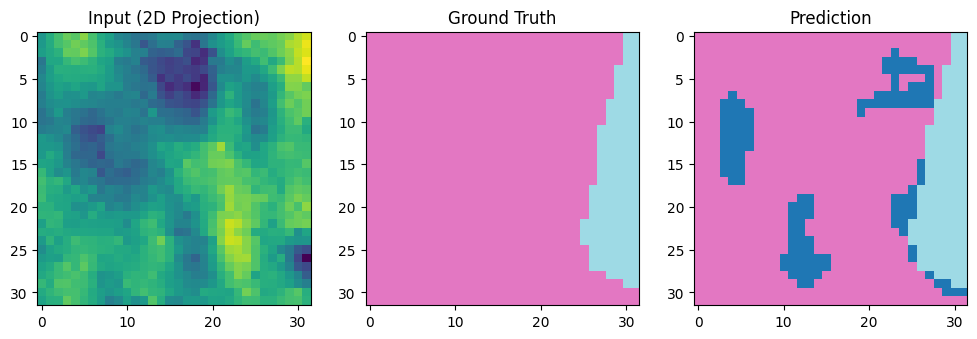

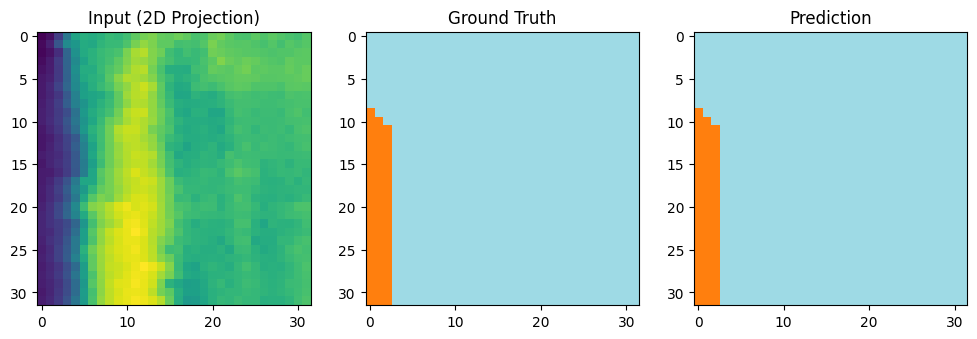

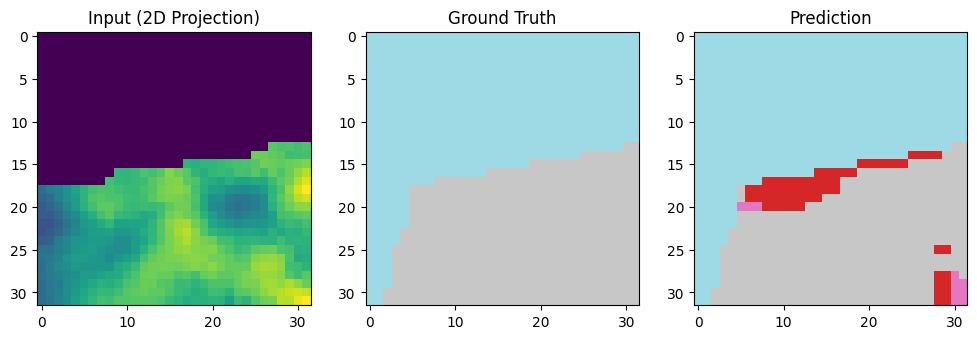

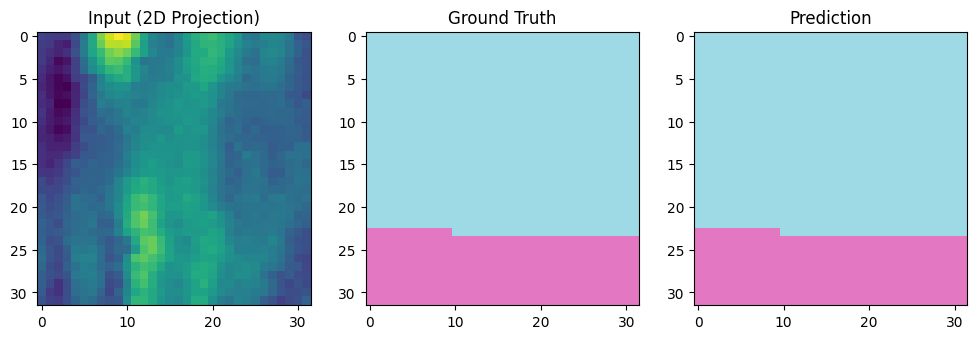

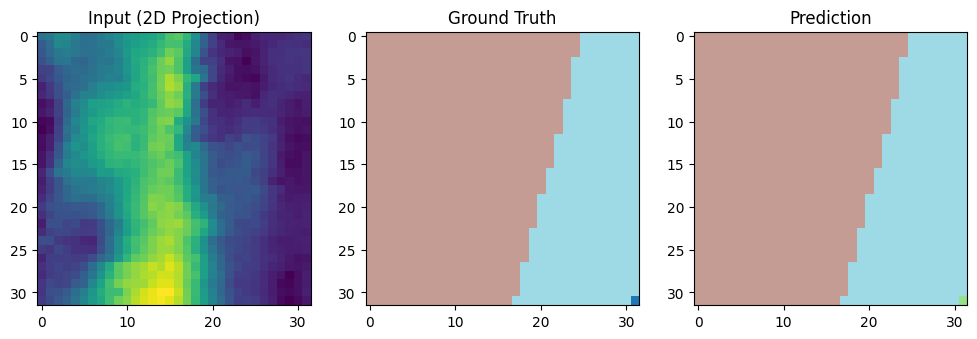

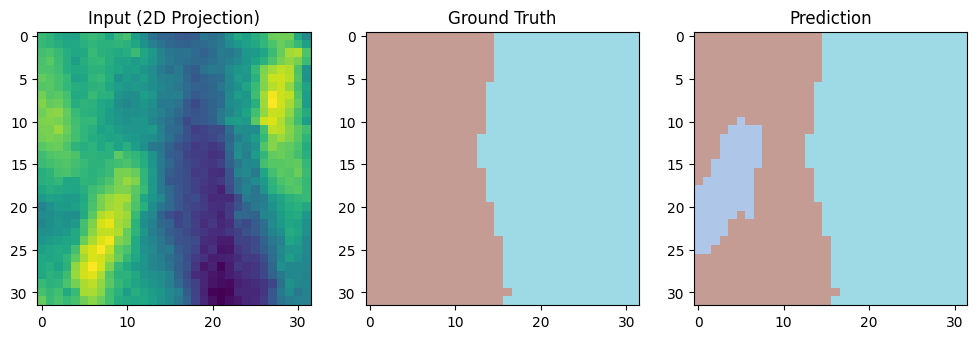

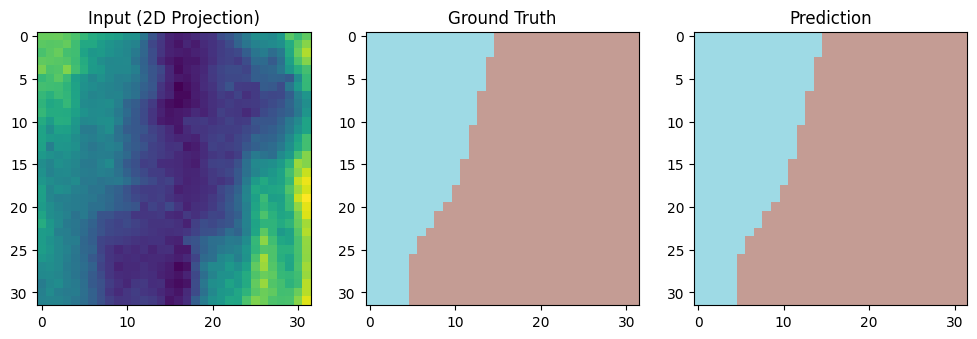

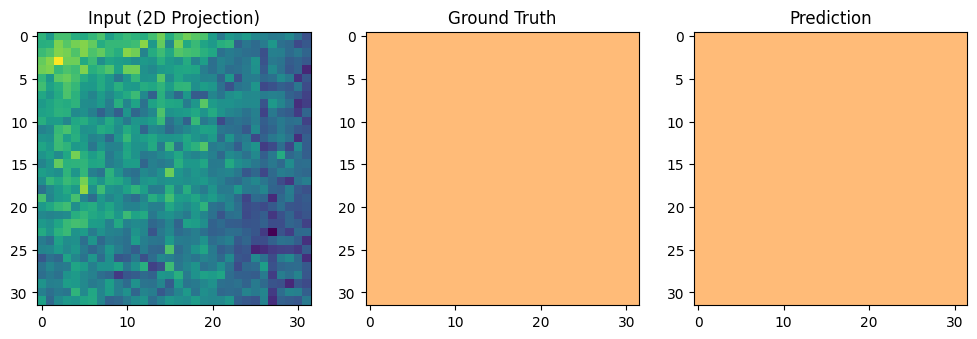

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt


def visualize_predictions_2d(model, dataloader):
    model.eval()
    for images, masks in dataloader:
      #images, masks = next(iter(dataloader))  # Get a single batch
      images, masks = images.to(device), masks.to(device)

      with torch.no_grad():
          outputs = model(images)
          preds = torch.argmax(outputs, dim=1)

      # set areas of prediction that is meant to be the background class as such:
      preds[masks == 255] = 255

    print("Inside visualization:", preds[:5])  # First few values

    # Compute the number of identical pixels
    matching_pixels = (preds == masks).sum().item()
    total_pixels = masks.numel()
    matching_percentage = (matching_pixels / total_pixels) * 100

    print(f"Matching Pixels: {matching_pixels}/{total_pixels} ({matching_percentage:.2f}%)")
  

      # Display predictions
    for i in range(min(10, len(images))):  # Show up to 4 examples

          plt.figure(figsize=(12, 4))

          # Collapse hyperspectral input to 2D by averaging across bands
          input_2d = images[i].mean(dim=0).cpu()  # Mean across channels

          plt.subplot(1, 3, 1)
          plt.title("Input (2D Projection)")
          plt.imshow(input_2d)  # Projected to 2D

          plt.subplot(1, 3, 2)
          plt.title("Ground Truth")
          plt.imshow(masks[i].cpu(), cmap='tab20', vmin=0, vmax=16)

          plt.subplot(1, 3, 3)
          plt.title("Prediction")
          plt.imshow(preds[i].cpu(), cmap='tab20', vmin=0, vmax=16)

          plt.show()

# Visualize predictions
visualize_predictions_2d(model, test_loader)


In [ ]:
import torch
import numpy as np
from collections import Counter

# Function to count pixels per class in both ground truth and predictions
def count_pixels_per_class(dataloader, model, num_classes=17, ignore_index=255):
    class_counts_gt = Counter()
    class_counts_pred = Counter()

    model.eval()
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Set ignored predictions to 255
            preds[masks == ignore_index] = ignore_index  

            # Convert to numpy and flatten
            masks_np = masks.cpu().numpy().flatten()
            preds_np = preds.cpu().numpy().flatten()

            # Remove ignored class pixels
            valid_mask = masks_np != ignore_index
            masks_np = masks_np[valid_mask]
            preds_np = preds_np[valid_mask]

            # Count pixels for each class
            unique_gt, counts_gt = np.unique(masks_np, return_counts=True)
            for cls, count in zip(unique_gt, counts_gt):
                class_counts_gt[cls] += count

            unique_pred, counts_pred = np.unique(preds_np, return_counts=True)
            for cls, count in zip(unique_pred, counts_pred):
                class_counts_pred[cls] += count

    print("\nClass Pixel Distribution (Ground Truth):")
    for cls in sorted(class_counts_gt.keys()):
        print(f"Class {cls}: {class_counts_gt[cls]} pixels")

    print("\nClass Pixel Distribution (Predictions):")
    for cls in sorted(class_counts_pred.keys()):
        print(f"Class {cls}: {class_counts_pred[cls]} pixels")

    return class_counts_gt, class_counts_pred


# Run the function on test data
class_pixel_counts_gt, class_pixel_counts_pred = count_pixels_per_class(test_loader, model)


Class Pixel Distribution (Ground Truth):
Class 0: 7925 pixels
Class 1: 5857 pixels
Class 2: 9956 pixels
Class 3: 24498 pixels
Class 4: 9511 pixels
Class 5: 14995 pixels
Class 6: 277 pixels
Class 7: 16001 pixels
Class 8: 2739 pixels
Class 9: 27336 pixels
Class 10: 33789 pixels
Class 11: 2255 pixels
Class 12: 14618 pixels
Class 13: 8773 pixels
Class 14: 48 pixels

Class Pixel Distribution (Predictions):
Class 0: 10799 pixels
Class 1: 4921 pixels
Class 2: 9847 pixels
Class 3: 24505 pixels
Class 4: 9684 pixels
Class 5: 17260 pixels
Class 6: 113 pixels
Class 7: 15495 pixels
Class 8: 2340 pixels
Class 9: 26765 pixels
Class 10: 26109 pixels
Class 11: 4401 pixels
Class 12: 16199 pixels
Class 13: 10098 pixels
Class 14: 4 pixels
Class 15: 38 pixels


In [34]:
import torch
import numpy as np
from collections import defaultdict

def compute_per_class_accuracy(dataloader, model, num_classes=17, ignore_index=255):
    # Counters for ground truth and correct predictions per class
    gt_counts = defaultdict(int)
    correct_counts = defaultdict(int)
    
    model.eval()  # Ensure model is in evaluation mode
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            
            # Get model outputs and predictions
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            # Make sure we don't update predictions where ground truth is ignore_index
            # (You could also leave preds as-is and then filter out ignore_index later)
            preds[masks == ignore_index] = ignore_index
            
            # Move tensors to CPU for numpy processing
            masks_np = masks.cpu().numpy()
            preds_np = preds.cpu().numpy()
            
            # Flatten arrays so we can easily iterate through pixels
            masks_np = masks_np.flatten()
            preds_np = preds_np.flatten()
            
            # Create a mask that filters out ignore_index pixels
            valid_mask = masks_np != ignore_index
            masks_np = masks_np[valid_mask]
            preds_np = preds_np[valid_mask]
            
            # Count pixels per class for ground truth and correct predictions
            for gt_val, pred_val in zip(masks_np, preds_np):
                gt_counts[gt_val] += 1
                if gt_val == pred_val:
                    correct_counts[gt_val] += 1
    
    # Print per-class accuracy and pixel counts
    print("Per-Class Accuracy (ignoring background class {}):".format(ignore_index))
    for cls in range(num_classes):
        if cls in gt_counts and gt_counts[cls] > 0:
            accuracy = (correct_counts[cls] / gt_counts[cls]) * 100
            print(f"Class {cls}: {accuracy:.2f}% (Correct: {correct_counts[cls]} / Total: {gt_counts[cls]} pixels)")
        else:
            print(f"Class {cls}: No ground truth pixels found.")
    
    return gt_counts, correct_counts

# Run the function on your test_loader and model
gt_counts, correct_counts = compute_per_class_accuracy(test_loader, model)


Per-Class Accuracy (ignoring background class 255):
Class 0: 94.93% (Correct: 7523 / Total: 7925 pixels)
Class 1: 73.31% (Correct: 4294 / Total: 5857 pixels)
Class 2: 95.04% (Correct: 9462 / Total: 9956 pixels)
Class 3: 99.69% (Correct: 24422 / Total: 24498 pixels)
Class 4: 95.43% (Correct: 9076 / Total: 9511 pixels)
Class 5: 78.71% (Correct: 11803 / Total: 14995 pixels)
Class 6: 37.18% (Correct: 103 / Total: 277 pixels)
Class 7: 94.03% (Correct: 15046 / Total: 16001 pixels)
Class 8: 68.89% (Correct: 1887 / Total: 2739 pixels)
Class 9: 97.50% (Correct: 26653 / Total: 27336 pixels)
Class 10: 73.74% (Correct: 24917 / Total: 33789 pixels)
Class 11: 95.48% (Correct: 2153 / Total: 2255 pixels)
Class 12: 76.45% (Correct: 11175 / Total: 14618 pixels)
Class 13: 98.15% (Correct: 8611 / Total: 8773 pixels)
Class 14: 8.33% (Correct: 4 / Total: 48 pixels)
Class 15: No ground truth pixels found.
Class 16: No ground truth pixels found.


Class 0: Color (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0))
Class 1: Color (np.float64(0.6823529411764706), np.float64(0.7803921568627451), np.float64(0.9098039215686274), np.float64(1.0))
Class 2: Color (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0))
Class 3: Color (np.float64(1.0), np.float64(0.7333333333333333), np.float64(0.47058823529411764), np.float64(1.0))
Class 4: Color (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0))
Class 5: Color (np.float64(0.596078431372549), np.float64(0.8745098039215686), np.float64(0.5411764705882353), np.float64(1.0))
Class 6: Color (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0))
Class 7: Color (np.float64(1.0), np.float64(0.596078431372549), np.float64(0.5882352941176471), np.float64(1.0))
Class 8:

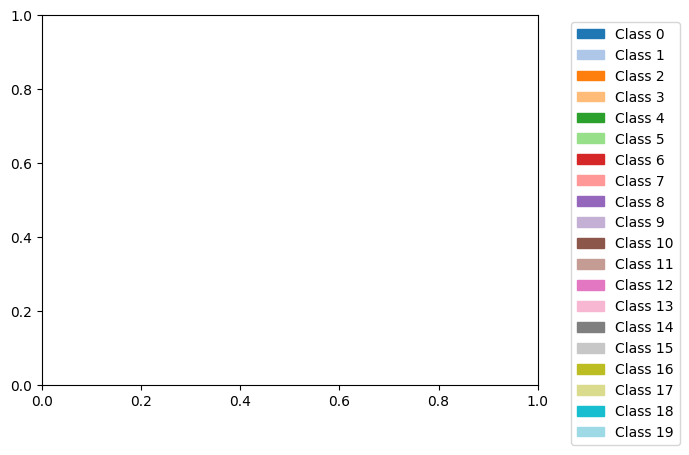

In [25]:

cmap = plt.get_cmap('tab20')

# Get the colors assigned to each class (0-19 for tab20)
num_classes = 20  # Adjust based on your actual number of classes
colors = [cmap(i) for i in np.linspace(0, 1, num_classes)]

# Print the color mapping
for class_id, color in enumerate(colors):
    print(f"Class {class_id}: Color {color}")

import matplotlib.patches as mpatches

# Generate legend handles for each class
legend_patches = [mpatches.Patch(color=cmap(i), label=f"Class {i}") for i in range(num_classes)]

# Display legend in the plot
plt.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.3, 1))
plt.show()


In [21]:
import torch
model.eval()
# Get a batch from the test dataloader
for images, masks in test_loader:
    images, masks = images.cpu(), masks.cpu()  # Move to CPU for analysis
    break  # Take only one batch

# Run the model to get predictions
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)  # Get predicted class indices

print("After visualization:", preds[:5])  # Check if they're different

# Compute the number of identical pixels
matching_pixels = (preds == masks).sum().item()
total_pixels = masks.numel()
matching_percentage = (matching_pixels / total_pixels) * 100

print(f"Matching Pixels: {matching_pixels}/{total_pixels} ({matching_percentage:.2f}%)")


After visualization: tensor([[[ 4,  4,  4,  ...,  7,  7,  7],
         [ 4,  4,  4,  ...,  7,  7,  7],
         [ 4,  4,  4,  ...,  7,  7,  7],
         ...,
         [ 4,  4,  5,  ...,  7,  7,  7],
         [ 4,  4, 12,  ...,  7,  7,  7],
         [ 4,  4, 12,  ...,  7,  7,  7]],

        [[ 4,  4,  4,  ...,  5,  5, 12],
         [ 4,  4,  5,  ...,  5,  5,  5],
         [12, 12,  5,  ...,  5,  5,  5],
         ...,
         [12, 12, 12,  ...,  5,  5,  5],
         [ 3,  3, 12,  ...,  5,  5,  5],
         [ 3,  3, 12,  ...,  5,  5, 10]],

        [[ 9,  9,  9,  ...,  9,  9,  9],
         [ 9,  9,  9,  ...,  9,  9,  9],
         [ 9,  9,  9,  ...,  9,  9,  9],
         ...,
         [ 9,  9,  9,  ...,  9,  9,  9],
         [ 9,  9,  9,  ...,  9,  9,  9],
         [ 9,  9,  9,  ...,  9,  9,  9]],

        [[10, 10, 10,  ..., 10, 10, 10],
         [10, 10, 10,  ..., 10, 10, 10],
         [10, 10, 10,  ..., 10, 10, 10],
         ...,
         [10, 10, 10,  ...,  4,  4,  4],
         [10, 1